# Biologically inspired Spinking neural network

### What are SNN?

Spiking Neural Networks are a class of artificial neural networks that mimic the behavior of biological neurons more closely than traditional neural networks. In SNNs, neurons communicate by sending discrete spikes, which represent changes in voltage across a neuron's membrane. These spikes are generated when the membrane potential exceeds a certain threshold.

human brain consists of approximately 86 billion neurons, which communicate through electrical impulses known as action potentials or spikes

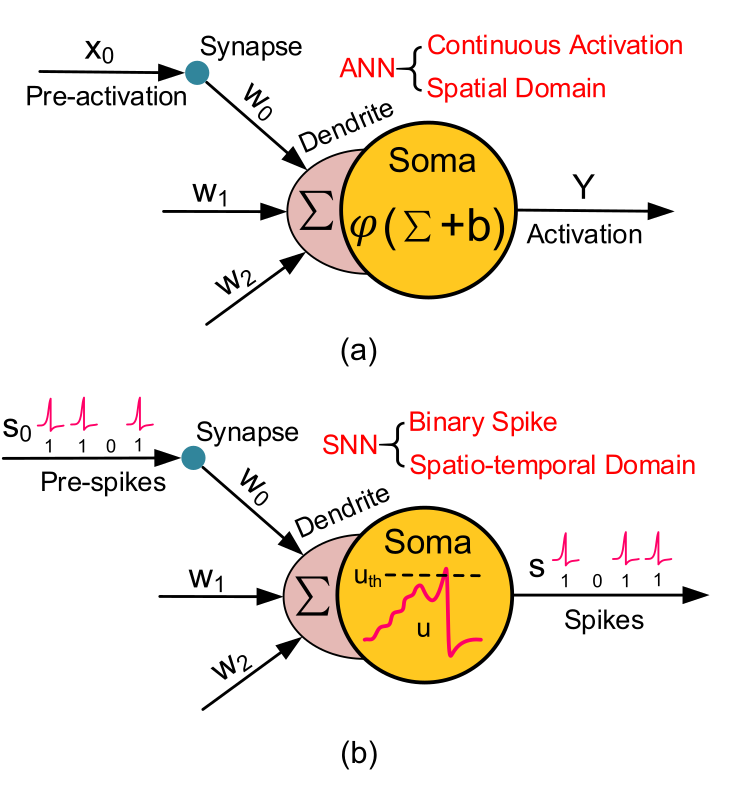

Key Concepts in Spiking Neural Networks
1. Neurons and Spikes
In SNNs, each neuron emits spikes based on its membrane potential, which is influenced by incoming spikes from connected neurons. When the membrane potential reaches a certain threshold, the neuron "fires" and emits a spike.

2. Temporal Coding
SNNs use temporal coding, where the timing of spikes carries information. This is different from rate coding in traditional neural networks, where information is represented by the frequency of neuron firing.

3. Synaptic Weights and Plasticity
Connections between neurons in SNNs are governed by synaptic weights, which determine the influence of one neuron's spike on another. Synaptic plasticity, often governed by rules such as Spike-Timing-Dependent Plasticity (STDP), allows these weights to change based on the timing of spikes, enabling learning.

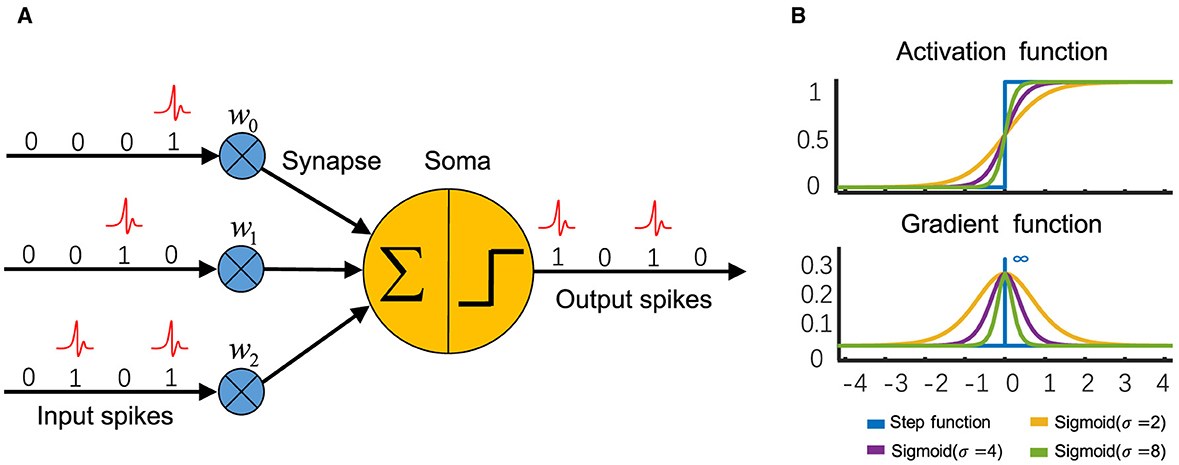

### LIF Leaky Integrated and fire Activation function

LIF activation function is a mathematical model that describes how neurons integrate input, leak over time, and emit spikes when thresholds are reached.

modeling the dynamics of neuronal membrane potential as it integrates synaptic input, leaks over time, and triggers a spike when a threshold is reached.

1. Fundamental Mechanism and Mathematical Structure
$$\frac{dV(t)}{dt} = -\frac{1}{\tau} [V(t) - V_r] + \frac{1}{C} I(t)$$


where V(t) - neuron's membrane potential, τ is the membrane time constant,
V_r is the reversal potential,
C is the membrane capacitance, and
I(t) is the input current.

* The leaky term
$$ -\frac{1}{\tau} [V(t) - V_r] $$ models the passive decay of the potential in the absence of input (leak), and the integration of I(t) reflects accumulation of synaptic current

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

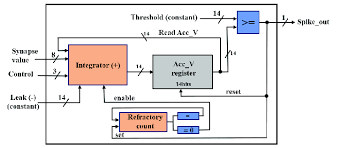

In [ ]:
# define lif neuron and synapse parameter

# Neuron Parameters
class LIFNeuron:
    def __init__(self, threshold, reset_value, leak_factor, refractory_period):
        self.threshold = threshold
        self.reset_value = reset_value
        self.leak_factor = leak_factor
        self.refractory_period = refractory_period
        self.membrane_potential = 0
        self.spike_time = -1
        self.refractory_end_time = -1

    def update(self, incoming_spikes, current_time):
        if current_time < self.refractory_end_time:
            return False

        self.membrane_potential *= self.decay_factor
        self.membrane_potential += np.sum(incoming_spikes)

        if self.membrane_potential >= self.threshold:
            self.spike_time = current_time
            self.membrane_potential = self.reset_value
            self.refractory_end_time = current_time + self.refractory_period
            return True
        return False

# Synapse Parameters
class Synapse:
    def __init__(self, weight):
        self.weight = weight

#### Define the STDP Learning Rule
The stdp function adjusts the synaptic weights based on the timing difference between the pre- and post-synaptic spikes

In [ ]:
# Spike-Timing-Dependent Plasticity (STDP)
def stdp(pre_spike_time, post_spike_time, weight, learning_rate, tau_positive, tau_negative):
    if pre_spike_time > 0 and post_spike_time > 0:
        delta_t = post_spike_time - pre_spike_time
        if delta_t > 0:
            return weight + learning_rate * np.exp(-delta_t / tau_positive)
        else:
            return weight - learning_rate * np.exp(delta_t / tau_negative)
    return weight